# Explainable Heart Disease Detection

Fast machine learning model selection and SHAP explainability.

Models:
- Logistic Regression
- Linear SVM
- RBF SVM

Target variable: `output`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy.stats import loguniform

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.base import clone

## 2. Read CSV Dataset

In [2]:
file_path = r"C:\ML\Heart Diseas Detection\heart.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape:
(303, 14)

First 5 rows:


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print("Column names:")

for i, column in enumerate(df.columns):
    print(f"{i}: {column}")

Column names:
0: age
1: sex
2: cp
3: trtbps
4: chol
5: fbs
6: restecg
7: thalachh
8: exng
9: oldpeak
10: slp
11: caa
12: thall
13: output


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## 3. Data Quality

In [6]:
print("Missing values:")
display(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:


age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


Total missing values: 0


In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


In [8]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")

print("Current dataset shape:", df.shape)

Duplicates removed.
Current dataset shape: (302, 14)


In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trtbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalachh,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exng,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


## 4. Target Distribution

In [10]:
print("Target distribution:")
display(df["output"].value_counts())

print("\nTarget percentage:")
display((df["output"].value_counts(normalize=True) * 100).round(2))

Target distribution:


1    164
0    138
Name: output, dtype: int64


Target percentage:


1    54.3
0    45.7
Name: output, dtype: float64

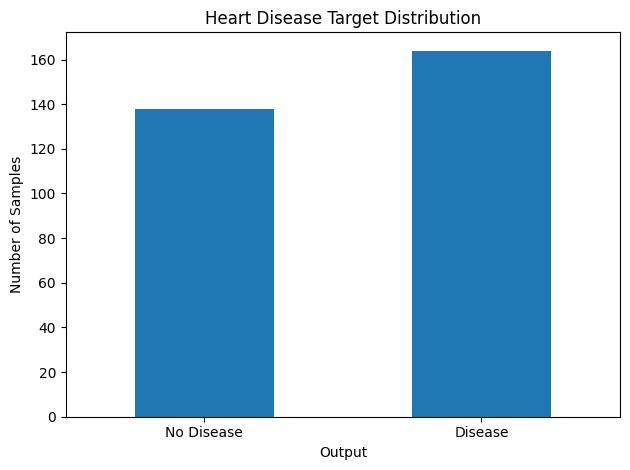

In [11]:
df["output"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Output")
plt.ylabel("Number of Samples")
plt.title("Heart Disease Target Distribution")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)

plt.tight_layout()
plt.show()

## 5. Prepare X and y

In [12]:
X = df.drop(columns=["output"])
y = df["output"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (302, 13)
y shape: (302,)


In [13]:
feature_names = X.columns.tolist()

print("Features:")

for i, feature in enumerate(feature_names):
    print(f"{i}: {feature}")

Features:
0: age
1: sex
2: cp
3: trtbps
4: chol
5: fbs
6: restecg
7: thalachh
8: exng
9: oldpeak
10: slp
11: caa
12: thall


In [14]:
print("Data types:")
display(X.dtypes)

Data types:


age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
dtype: object

## 6. Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 13)
X_test : (61, 13)
y_train: (241,)
y_test : (61,)


# 7. Define Models

RandomizedSearchCV is used to reduce computational cost.

SVM probability estimation is disabled during hyperparameter optimization.

In [16]:
models = {

    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=2000,
                solver="lbfgs",
                random_state=42
            ))
        ]),
        {
            "classifier__C": loguniform(0.001, 1000)
        },
        10
    ),

    "Linear SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", SVC(
                kernel="linear",
                probability=False,
                random_state=42
            ))
        ]),
        {
            "classifier__C": loguniform(0.001, 1000)
        },
        10
    ),

    "RBF SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", SVC(
                kernel="rbf",
                probability=False,
                random_state=42
            ))
        ]),
        {
            "classifier__C": loguniform(0.1, 1000),
            "classifier__gamma": loguniform(0.0001, 1)
        },
        15
    )
}

In [17]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("3-fold Stratified CV configured.")

3-fold Stratified CV configured.


# 8. Fast RandomizedSearchCV

In [18]:
trained_models = {}
results = []
best_parameters = {}
cv_scores = {}

In [19]:
for name, (model, param_distributions, n_iter) in models.items():

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        return_train_score=False
    )

    search.fit(X_train, y_train)

    best_estimator = search.best_estimator_

    trained_models[name] = best_estimator
    best_parameters[name] = search.best_params_
    cv_scores[name] = search.best_score_

    y_pred = best_estimator.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "CV F1": search.best_score_,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print("\nBest parameters:")
    print(search.best_params_)
    print(f"CV F1       : {search.best_score_:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall   : {recall:.4f}")
    print(f"Test F1       : {f1:.4f}")


Training: Logistic Regression
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters:
{'classifier__C': 0.008632008168602538}
CV F1       : 0.8564
Test Accuracy: 0.8197
Test Precision: 0.7619
Test Recall   : 0.9697
Test F1       : 0.8533

Training: Linear SVM
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters:
{'classifier__C': 0.1767016940294795}
CV F1       : 0.8518
Test Accuracy: 0.8197
Test Precision: 0.7619
Test Recall   : 0.9697
Test F1       : 0.8533

Training: RBF SVM
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters:
{'classifier__C': 28.016351587162582, 'classifier__gamma': 0.0003613894271216529}
CV F1       : 0.8623
Test Accuracy: 0.8197
Test Precision: 0.7619
Test Recall   : 0.9697
Test F1       : 0.8533


# 9. Compare Models

In [20]:
results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values(by="F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

,Model,CV F1,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.856436,0.819672,0.761905,0.969697,0.853333
1,Linear SVM,0.851822,0.819672,0.761905,0.969697,0.853333
2,RBF SVM,0.862328,0.819672,0.761905,0.969697,0.853333


# 10. Select Best Model

In [21]:
best_model_name = results_df.loc[
    results_df["F1"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Model:", best_model_name)
print("Best parameters:", best_parameters[best_model_name])

display(
    results_df[results_df["Model"] == best_model_name]
)

BEST MODEL
Model: Logistic Regression
Best parameters: {'classifier__C': 0.008632008168602538}


,Model,CV F1,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.856436,0.819672,0.761905,0.969697,0.853333


# 11. Best Model Predictions

In [22]:
best_y_pred = best_model.predict(X_test)

print("Prediction completed.")
print("Number of predictions:", len(best_y_pred))
print("First 10 predictions:", best_y_pred[:10])

Prediction completed.
Number of predictions: 61
First 10 predictions: [0 0 0 1 1 0 1 0 1 1]


In [23]:
print(classification_report(
    y_test,
    best_y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



# 12. Confusion Matrix

In [24]:
cm = confusion_matrix(y_test, best_y_pred)

print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

[[18 10]
 [ 1 32]]
TN = 18
FP = 10
FN = 1
TP = 32


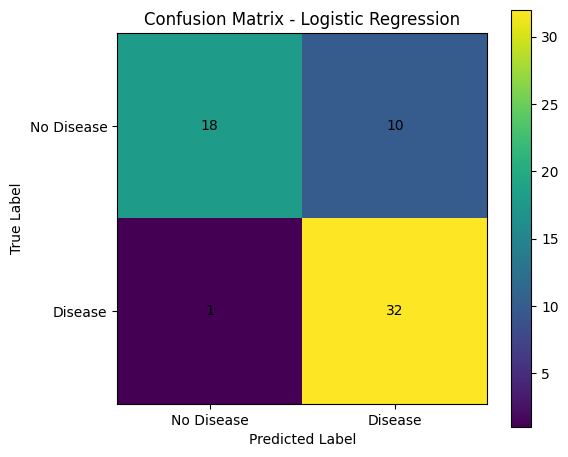

In [25]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.yticks([0, 1], ["No Disease", "Disease"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# 13. Sensitivity and Specificity

In [26]:
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Sensitivity: 0.9697
Specificity: 0.6429


In [27]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity / Recall",
        "Specificity",
        "F1-score"
    ],
    "Value": [
        accuracy_score(y_test, best_y_pred),
        precision_score(y_test, best_y_pred, zero_division=0),
        sensitivity,
        specificity,
        f1_score(y_test, best_y_pred, zero_division=0)
    ]
})

final_metrics["Value"] = final_metrics["Value"].round(4)

display(final_metrics)

,Metric,Value
0,Accuracy,0.8197
1,Precision,0.7619
2,Sensitivity / Recall,0.9697
3,Specificity,0.6429
4,F1-score,0.8533


# 14. Prepare Final Model for Probability Prediction

In [28]:
final_model = clone(best_model)

# LogisticRegression already supports predict_proba().
# SVC requires probability=True.

if best_model_name == "Logistic Regression":

    final_model.fit(
        X_train,
        y_train
    )

    print("Logistic Regression supports predict_proba().")

else:

    final_model.set_params(
        classifier__probability=True
    )

    final_model.fit(
        X_train,
        y_train
    )

    print("SVM probability=True enabled.")

print("Final model:", best_model_name)

Logistic Regression supports predict_proba().
Final model: Logistic Regression


# 15. Probability Prediction

In [29]:
y_proba = final_model.predict_proba(X_test)

print("Probability matrix shape:", y_proba.shape)

display(pd.DataFrame(
    y_proba[:10],
    columns=["P(No Disease)", "P(Disease)"]
))

Probability matrix shape: (61, 2)


,P(No Disease),P(Disease)
0,0.639928,0.360072
1,0.578380,0.421620
2,0.787928,0.212072
3,0.421228,0.578772
4,0.397065,0.602935
5,0.742641,0.257359
6,0.226539,0.773461
7,0.658085,0.341915
8,0.255304,0.744696
9,0.381038,0.618962


# 16. ROC-AUC

In [30]:
y_proba_positive = y_proba[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_proba_positive
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8864


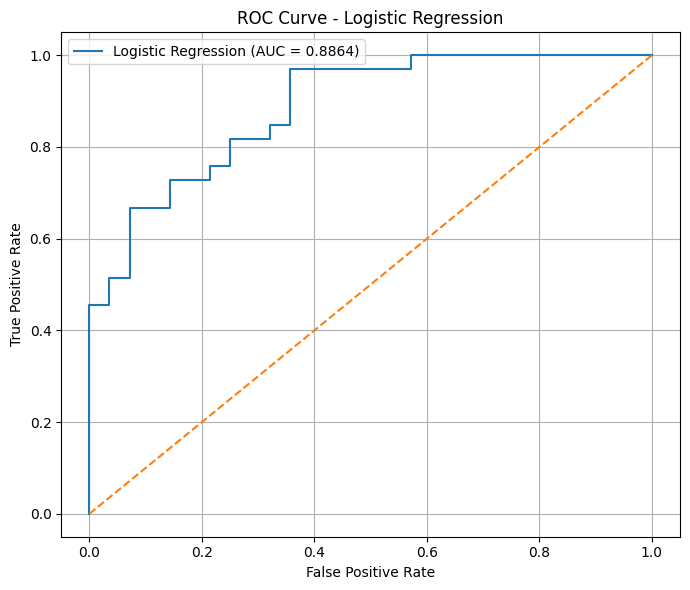

In [31]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_positive
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# 17. SHAP Preparation

The scaler is extracted from the pipeline and the data are transformed before SHAP is applied. This keeps the feature count and feature names consistent.

In [32]:
scaler = final_model.named_steps["scaler"]
classifier = final_model.named_steps["classifier"]

print("Best model:", best_model_name)
print("Classifier:", classifier)

print("Number of original features:", X_train.shape[1])

Best model: Logistic Regression
Classifier: LogisticRegression(C=0.008632008168602538, max_iter=2000, random_state=42)
Number of original features: 13


In [33]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (241, 13)
X_test_scaled shape : (61, 13)


In [34]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)

print("Number of SHAP features:", len(X_test_scaled_df.columns))
print("Feature names:")
print(X_test_scaled_df.columns.tolist())

Number of SHAP features: 13
Feature names:
['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']


# 18. Create SHAP Explainer

- Logistic Regression → LinearExplainer
- Linear SVM → LinearExplainer
- RBF SVM → KernelExplainer

In [35]:
if best_model_name == "Logistic Regression":

    print("Using LinearExplainer for Logistic Regression.")

    explainer = shap.LinearExplainer(
        classifier,
        X_train_scaled_df
    )

elif best_model_name == "Linear SVM":

    print("Using LinearExplainer for Linear SVM.")

    explainer = shap.LinearExplainer(
        classifier,
        X_train_scaled_df
    )

elif best_model_name == "RBF SVM":

    print("Using KernelExplainer for RBF SVM.")

    # Small background set for faster SHAP computation
    background = shap.sample(
        X_train_scaled_df,
        10,
        random_state=42
    )

    explainer = shap.KernelExplainer(
        classifier.predict_proba,
        background
    )

else:

    raise ValueError(
        f"Unknown model: {best_model_name}"
    )

print("SHAP explainer created successfully.")

Using LinearExplainer for Logistic Regression.
SHAP explainer created successfully.


# 19. Calculate SHAP Values

In [36]:
# Use a small number of test samples initially
X_shap = X_test_scaled_df.iloc[:10]

print("Samples used for SHAP:", X_shap.shape[0])
print("Features used for SHAP:", X_shap.shape[1])

shap_values = explainer(X_shap)

print("SHAP calculation completed.")

Samples used for SHAP: 10
Features used for SHAP: 13
SHAP calculation completed.


# 20. Inspect SHAP Output

In [37]:
print("SHAP object type:")
print(type(shap_values))

print("\nSHAP shape:")
print(shap_values.shape)

print("\nNumber of features:")
print(len(X_shap.columns))

print("\nFeature names:")
print(X_shap.columns.tolist())

SHAP object type:
<class 'shap._explanation.Explanation'>

SHAP shape:
(10, 13)

Number of features:
13

Feature names:
['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']


# 21. SHAP Global Feature Importance

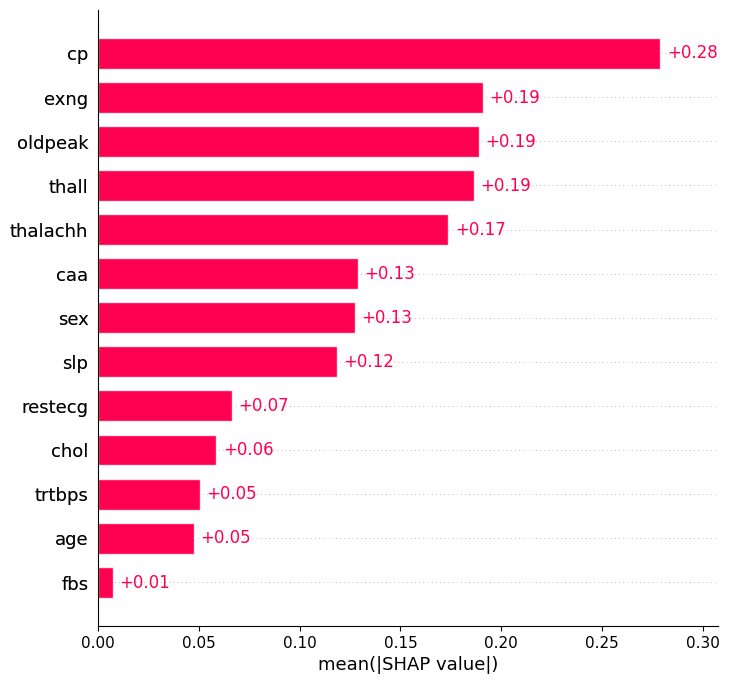

In [38]:
shap.plots.bar(
    shap_values,
    max_display=len(feature_names)
)

# 22. SHAP Beeswarm Plot

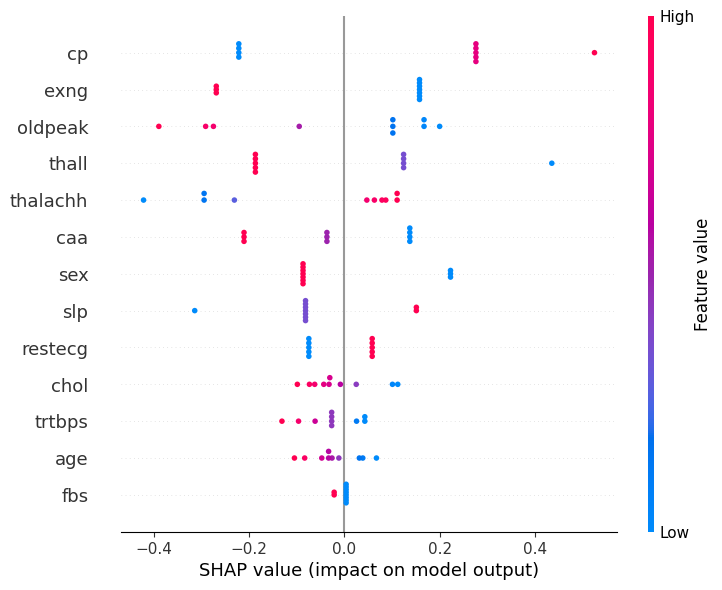

In [39]:
shap.plots.beeswarm(
    shap_values,
    max_display=len(feature_names)
)

# 23. Individual Patient Explanation

In [40]:
sample_index = 0

actual_class = y_test.iloc[sample_index]

predicted_class = final_model.predict(
    X_test.iloc[[sample_index]]
)[0]

disease_probability = final_model.predict_proba(
    X_test.iloc[[sample_index]]
)[0, 1]

print(f"Sample index        : {sample_index}")
print(f"Actual class        : {actual_class}")
print(f"Predicted class     : {predicted_class}")
print(f"Disease probability : {disease_probability:.4f}")

Sample index        : 0
Actual class        : 0
Predicted class     : 0
Disease probability : 0.3601


# 24. SHAP Waterfall Plot

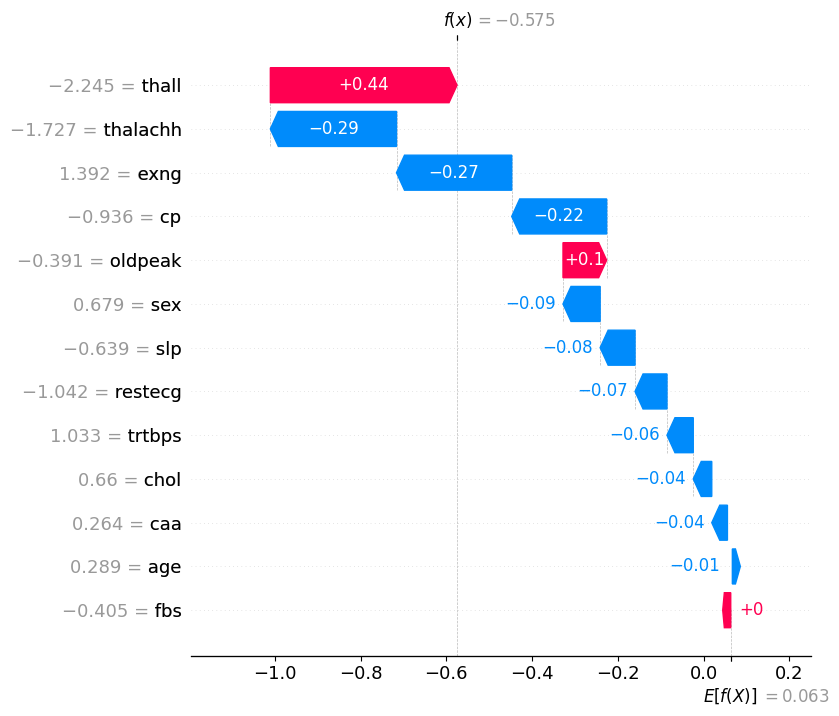

In [41]:
shap.plots.waterfall(
    shap_values[0],
    max_display=len(feature_names)
)

In [42]:
# ============================================================
# XAI Packages
# ============================================================

#%pip install -q lime alibi PyALE

In [43]:
# ============================================================
# Additional XAI Imports
# ============================================================

from sklearn.inspection import (
    PartialDependenceDisplay,
    permutation_importance
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score

from lime.lime_tabular import LimeTabularExplainer

from alibi.explainers import AnchorTabular

import warnings

warnings.filterwarnings("ignore")

print("Additional XAI libraries imported successfully.")

Additional XAI libraries imported successfully.


In [44]:
# ============================================================
# XAI Configuration
# ============================================================

XAI_SAMPLE_SIZE = min(100, len(X_test))

X_explain = X_test.iloc[:XAI_SAMPLE_SIZE].copy()

print("XAI sample size:", len(X_explain))
print("Number of features:", X_explain.shape[1])

XAI sample size: 61
Number of features: 13


In [45]:
# ============================================================
# Model-Agnostic Prediction Functions
# ============================================================

def predict_class(X_input):
    """
    Class prediction using the complete pipeline.
    """

    if isinstance(X_input, np.ndarray):
        X_input = pd.DataFrame(
            X_input,
            columns=feature_names
        )

    return final_model.predict(X_input)


def predict_probability(X_input):
    """
    Probability of Heart Disease = class 1.
    """

    if isinstance(X_input, np.ndarray):
        X_input = pd.DataFrame(
            X_input,
            columns=feature_names
        )

    return final_model.predict_proba(X_input)[:, 1]


def predict_probability_matrix(X_input):
    """
    Full probability matrix.
    """

    if isinstance(X_input, np.ndarray):
        X_input = pd.DataFrame(
            X_input,
            columns=feature_names
        )

    return final_model.predict_proba(X_input)


print("Prediction functions created.")

Prediction functions created.


Generating Partial Dependence Plots...


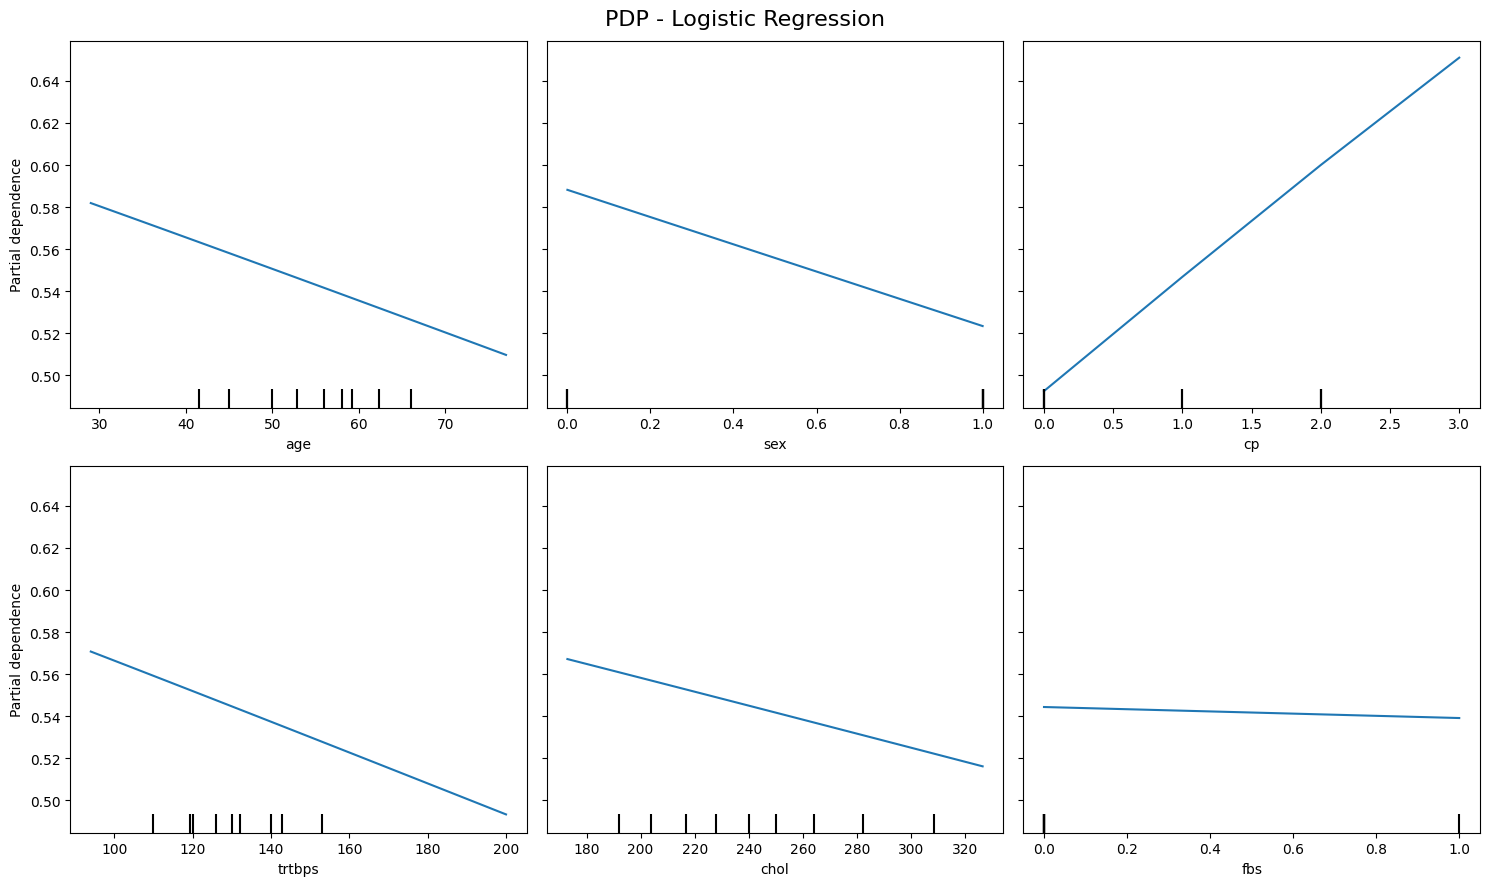

In [46]:
# ============================================================
# PDP - Partial Dependence Plot
# ============================================================

print("Generating Partial Dependence Plots...")

features_to_plot = feature_names[:min(6, len(feature_names))]

fig, ax = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 9)
)

PartialDependenceDisplay.from_estimator(
    final_model,
    X_train,
    features=features_to_plot,
    response_method="predict_proba",
    target=1,
    ax=ax
)

fig.suptitle(
    f"PDP - {best_model_name}",
    fontsize=16
)

plt.tight_layout()
plt.show()

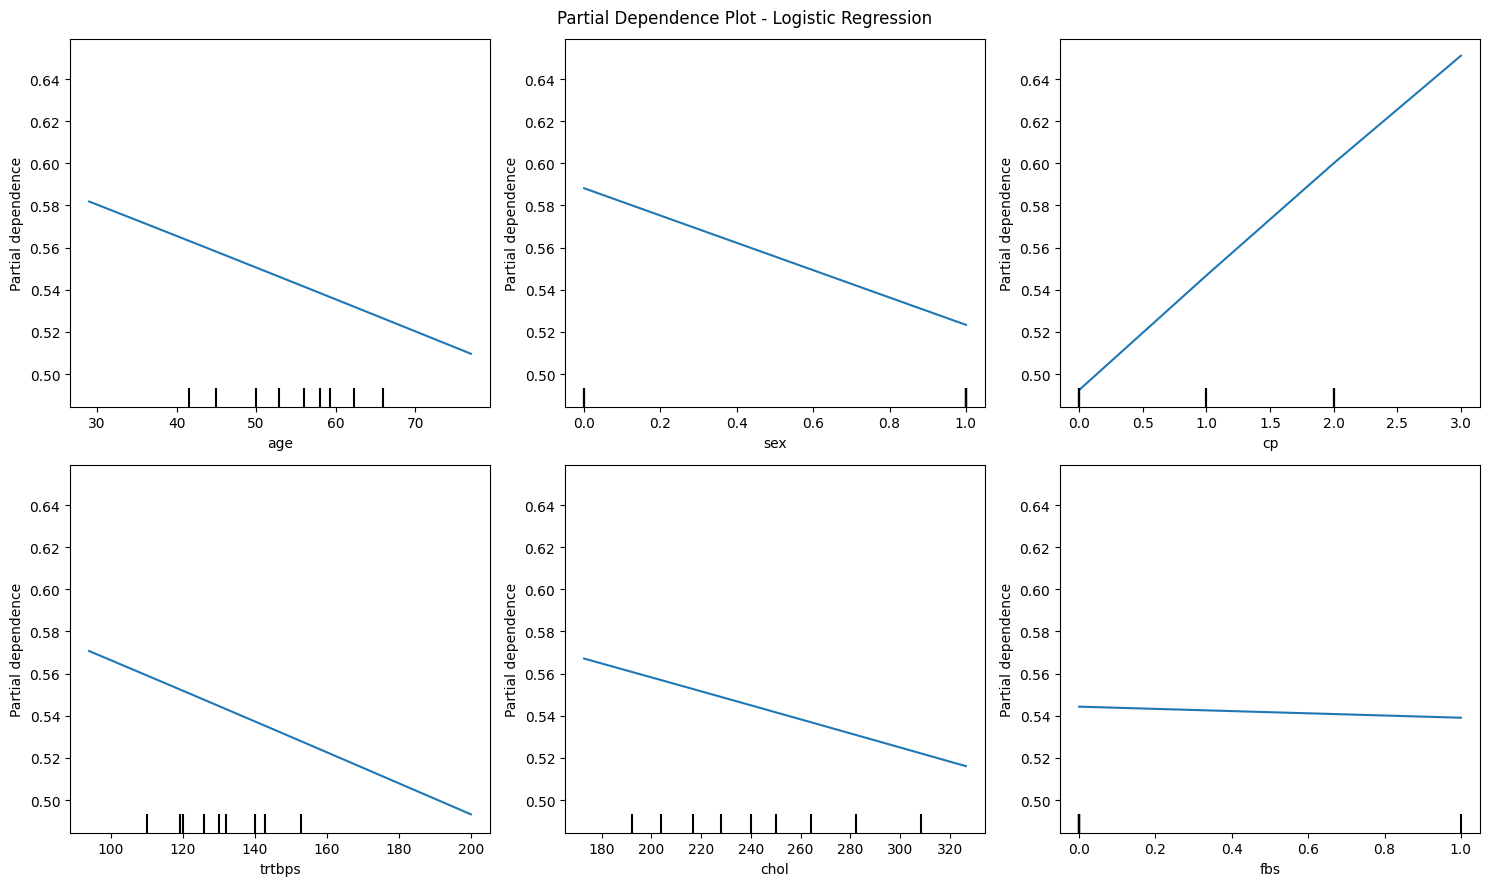

In [47]:
# ============================================================
# PDP - Automatic Layout
# ============================================================

n_features_plot = min(6, len(feature_names))

fig, ax = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

ax = ax.flatten()

PartialDependenceDisplay.from_estimator(
    final_model,
    X_train,
    features=feature_names[:n_features_plot],
    response_method="predict_proba",
    target=1,
    ax=ax[:n_features_plot]
)

for i in range(n_features_plot, len(ax)):
    ax[i].set_visible(False)

plt.suptitle(
    f"Partial Dependence Plot - {best_model_name}"
)

plt.tight_layout()
plt.show()

ICE feature: age


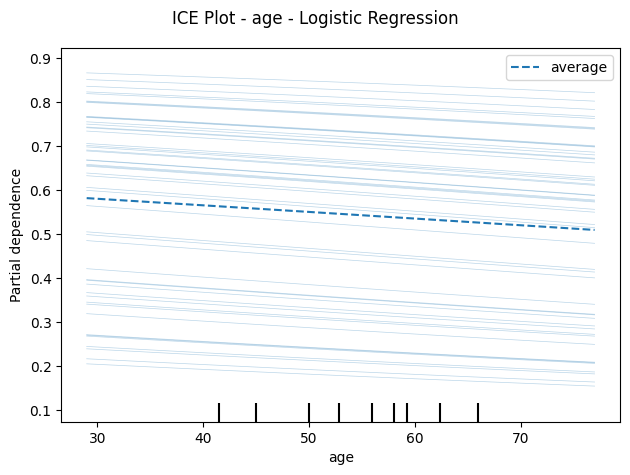

In [48]:
# ============================================================
# ICE - Individual Conditional Expectation
# ============================================================

ice_feature = feature_names[0]

print("ICE feature:", ice_feature)

PartialDependenceDisplay.from_estimator(
    final_model,
    X_train,
    features=[ice_feature],
    kind="both",
    centered=False,
    response_method="predict_proba",
    target=1,
    subsample=min(50, len(X_train)),
    random_state=42
)

plt.suptitle(
    f"ICE Plot - {ice_feature} - {best_model_name}"
)

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# Define top features for ALE
# ============================================================

shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "SHAP Importance": shap_importance
}).sort_values(
    by="SHAP Importance",
    ascending=False
)

top_features = shap_feature_importance["Feature"].tolist()

print("Top features for ALE:")
print(top_features[:10])

Top features for ALE:
['cp', 'exng', 'oldpeak', 'thall', 'thalachh', 'caa', 'sex', 'slp', 'restecg', 'chol']


PyALE._ALE_generic:INFO: Discrete feature detected.


Generating ALE plots...
ALE for: cp


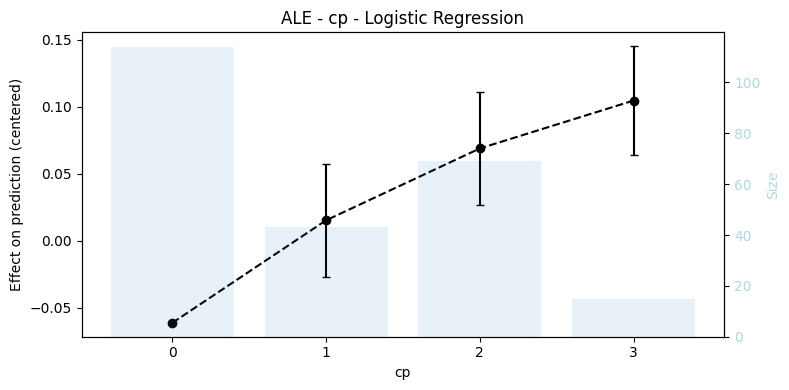

PyALE._ALE_generic:INFO: Discrete feature detected.


ALE for: exng


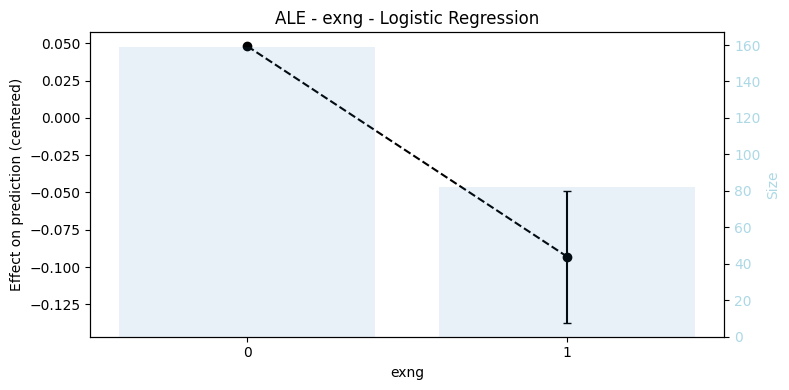

PyALE._ALE_generic:INFO: Continuous feature detected.


ALE for: oldpeak


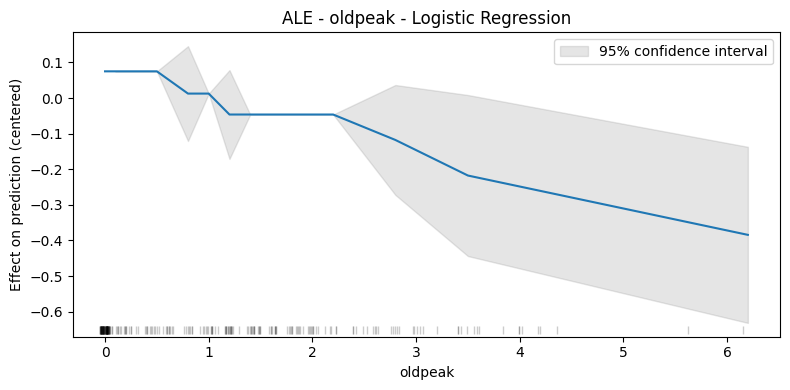

In [52]:
# ============================================================
# ALE - Accumulated Local Effects
# ============================================================

from PyALE import ale

print("Generating ALE plots...")

for feature in top_features[:3]:

    print(f"ALE for: {feature}")

    ale(
        X=X_train,
        model=final_model,
        feature=[feature],
        grid_size=20,
        include_CI=True,
        plot=True
    )

    plt.title(
        f"ALE - {feature} - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

PyALE._ALE_generic:INFO: Discrete feature detected.


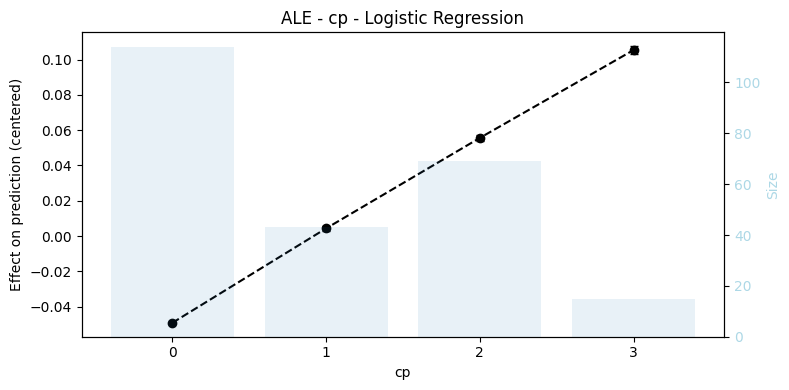

PyALE._ALE_generic:INFO: Discrete feature detected.


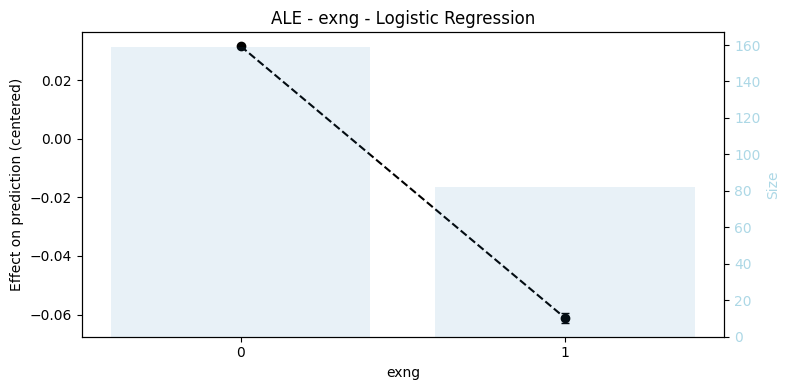

PyALE._ALE_generic:INFO: Continuous feature detected.


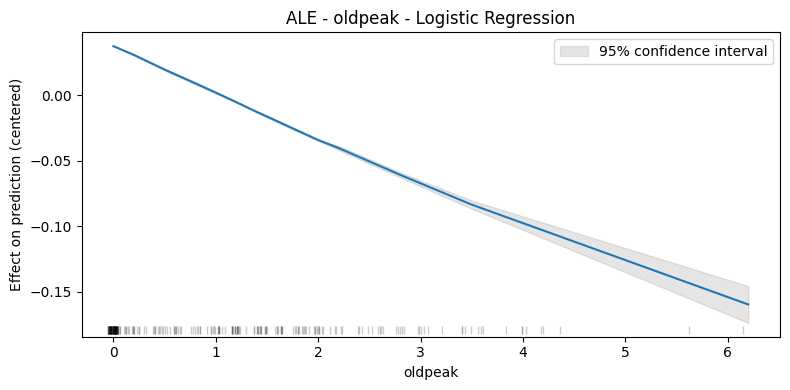

In [53]:
# ============================================================
# ALE using probability wrapper
# ============================================================

class ProbabilityModel:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return self.model.predict_proba(X)[:, 1]


probability_model = ProbabilityModel(final_model)

for feature in top_features[:3]:

    ale(
        X=X_train,
        model=probability_model,
        feature=[feature],
        grid_size=20,
        include_CI=True,
        plot=True
    )

    plt.title(
        f"ALE - {feature} - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

In [54]:
# ============================================================
# Permutation Feature Importance
# ============================================================

print("Calculating Permutation Feature Importance...")

pfi = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": pfi.importances_mean,
    "Std": pfi.importances_std
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance_df)

Calculating Permutation Feature Importance...


,Feature,Importance,Std
0,sex,0.040603,0.010992
1,thalachh,0.040165,0.022862
2,cp,0.040033,0.026882
3,caa,0.035742,0.022208
4,thall,0.034148,0.019257
5,oldpeak,0.018454,0.015426
6,trtbps,0.016376,0.010517
7,exng,0.015884,0.026108
8,restecg,0.010032,0.008520
9,slp,0.008165,0.010772


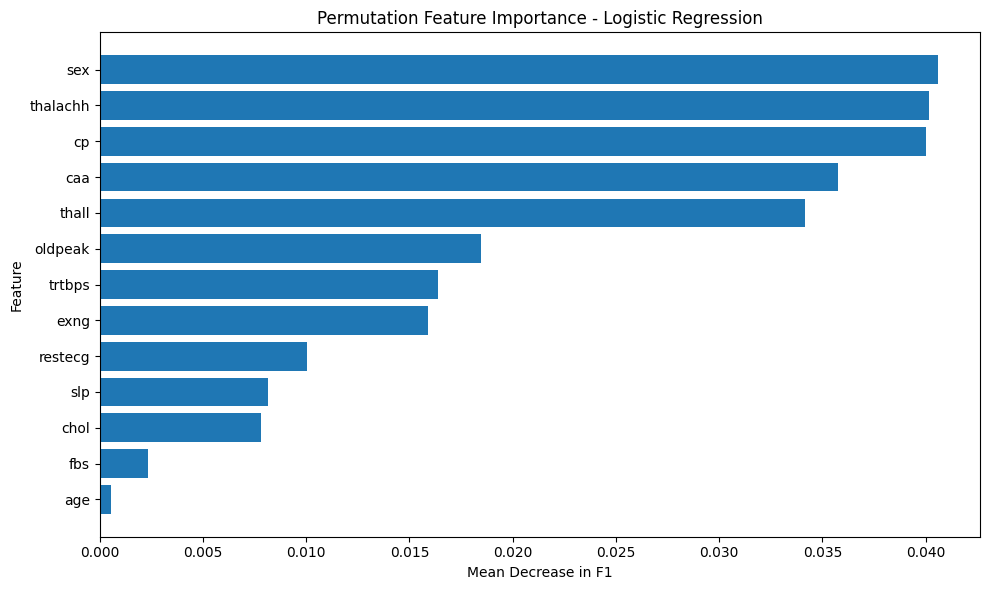

In [55]:
# ============================================================
# PFI Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Mean Decrease in F1")
plt.ylabel("Feature")

plt.title(
    f"Permutation Feature Importance - {best_model_name}"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# Global Surrogate Model
# ============================================================

surrogate = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

surrogate.fit(
    X_train,
    final_model.predict(X_train)
)

surrogate_prediction = surrogate.predict(X_test)

surrogate_accuracy = accuracy_score(
    final_model.predict(X_test),
    surrogate_prediction
)

print(
    f"Surrogate fidelity accuracy: "
    f"{surrogate_accuracy:.4f}"
)

Surrogate fidelity accuracy: 0.8361


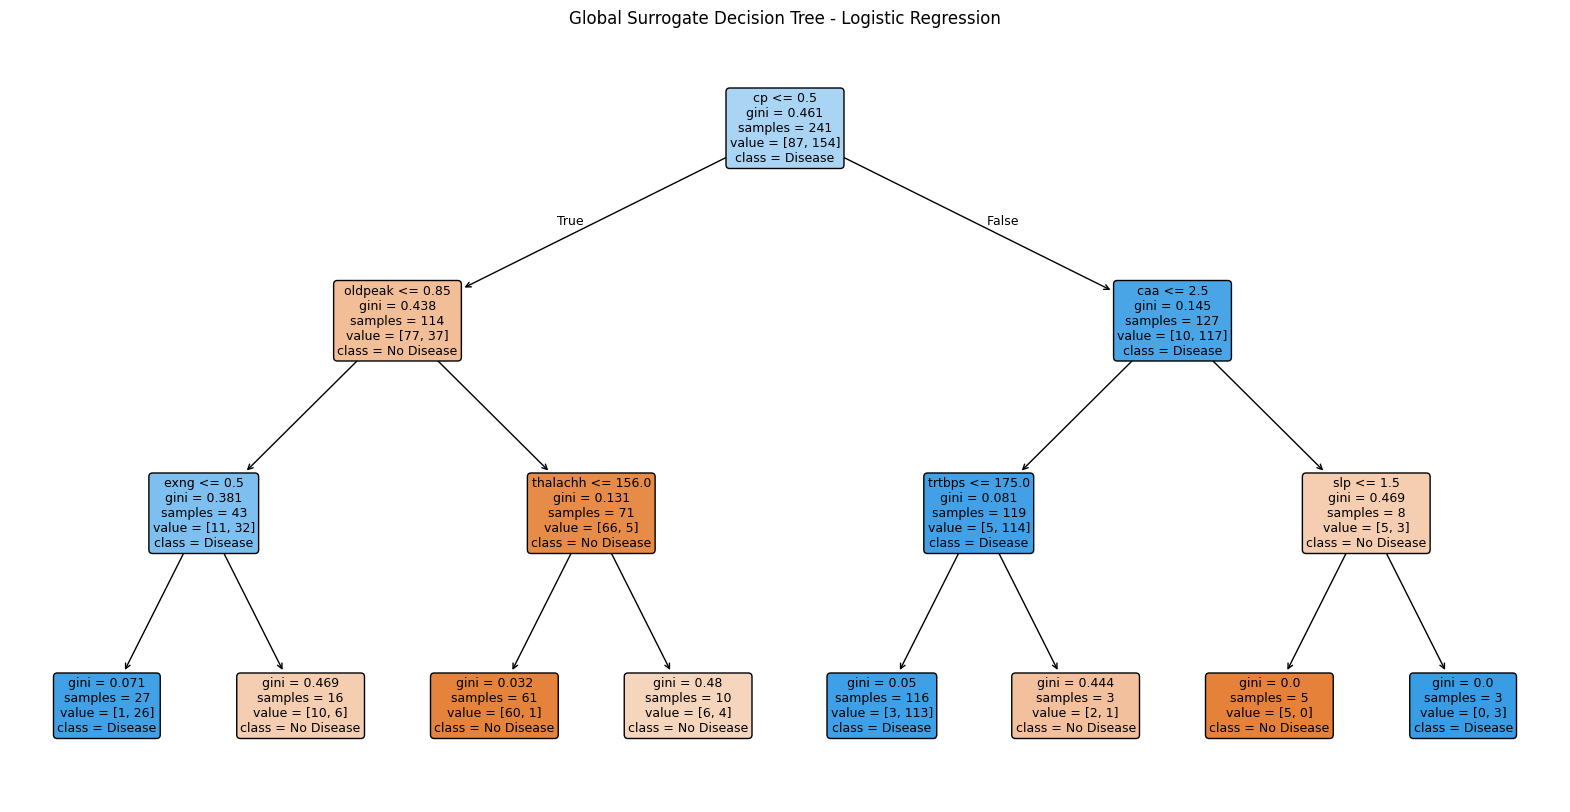

In [57]:
# ============================================================
# Global Surrogate Tree
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    surrogate,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    f"Global Surrogate Decision Tree - {best_model_name}"
)

plt.show()

In [58]:
# ============================================================
# LIME Explainer
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=[
        "No Disease",
        "Disease"
    ],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created.")

LIME explainer created.


In [59]:
# ============================================================
# LIME - Individual Explanation
# ============================================================

lime_index = 0

lime_instance = X_test.iloc[lime_index].values

lime_exp = lime_explainer.explain_instance(
    lime_instance,
    predict_probability_matrix,
    num_features=len(feature_names),
    num_samples=3000
)

print(
    "Actual class:",
    y_test.iloc[lime_index]
)

print(
    "Predicted class:",
    final_model.predict(
        X_test.iloc[[lime_index]]
    )[0]
)

print(
    "Disease probability:",
    final_model.predict_proba(
        X_test.iloc[[lime_index]]
    )[0, 1]
)

Actual class: 0
Predicted class: 0
Disease probability: 0.36007212008550205


In [60]:
# ============================================================
# LIME Feature Contributions
# ============================================================

lime_exp.show_in_notebook(
    show_table=True
)

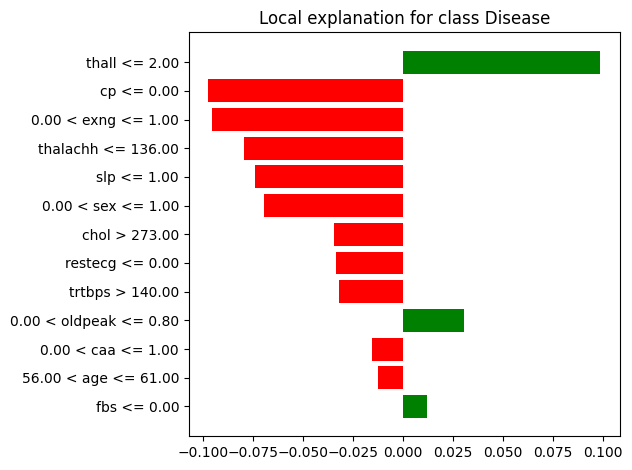

In [61]:
# Alternative LIME visualization

fig = lime_exp.as_pyplot_figure()

plt.tight_layout()
plt.show()

In [62]:
# LIME explanation as text

for feature, weight in lime_exp.as_list():

    print(
        f"{feature:40s} "
        f"{weight:+.4f}"
    )

thall <= 2.00                            +0.0987
cp <= 0.00                               -0.0971
0.00 < exng <= 1.00                      -0.0952
thalachh <= 136.00                       -0.0794
slp <= 1.00                              -0.0739
0.00 < sex <= 1.00                       -0.0695
chol > 273.00                            -0.0342
restecg <= 0.00                          -0.0332
trtbps > 140.00                          -0.0316
0.00 < oldpeak <= 0.80                   +0.0304
0.00 < caa <= 1.00                       -0.0152
56.00 < age <= 61.00                     -0.0123
fbs <= 0.00                              +0.0121


In [63]:
# ============================================================
# Anchor Explainer
# ============================================================

anchor_explainer = AnchorTabular(
    predictor=predict_class,
    feature_names=feature_names
)

anchor_explainer.fit(
    X_train.values,
    disc_perc=(25, 50, 75)
)

print("Anchor explainer fitted.")

Anchor explainer fitted.


In [64]:
# ============================================================
# Generate Anchor Explanation
# ============================================================

anchor_index = 0

anchor_instance = X_test.iloc[
    anchor_index
].values

anchor_exp = anchor_explainer.explain(
    anchor_instance,
    threshold=0.90,
    max_anchor_size=5
)

print("Anchor explanation:")
print()

for rule in anchor_exp.data["anchor"]:

    print("IF", rule)

print()

print(
    "Precision:",
    anchor_exp.data["precision"]
)

print(
    "Coverage:",
    anchor_exp.data["coverage"]
)

Anchor explanation:

IF thalachh <= 136.00
IF exng > 0.00
IF cp <= 0.00

Precision: 0.9815354713313897
Coverage: 0.13278008298755187


In [66]:
# ============================================================
# Counterfactual Explanation
# ============================================================

from sklearn.metrics import pairwise_distances


def find_counterfactual(
    model,
    X_data,
    instance,
    feature_names
):

    instance_prediction = model.predict(
        instance
    )[0]

    all_predictions = model.predict(
        X_data
    )

    opposite_indices = np.where(
        all_predictions != instance_prediction
    )[0]

    if len(opposite_indices) == 0:

        return None

    X_reference = X_data.iloc[
        opposite_indices
    ]

    # Standardize distances so features with larger
    # numerical scales do not dominate.

    scaler_cf = StandardScaler()

    combined = pd.concat(
        [
            X_data,
            instance
        ],
        axis=0
    )

    scaler_cf.fit(combined)

    X_reference_scaled = scaler_cf.transform(
        X_reference
    )

    instance_scaled = scaler_cf.transform(
        instance
    )

    distances = pairwise_distances(
        instance_scaled,
        X_reference_scaled,
        metric="euclidean"
    )[0]

    nearest_index = np.argmin(
        distances
    )

    counterfactual = X_reference.iloc[
        [nearest_index]
    ].copy()

    return counterfactual

In [67]:
# ============================================================
# Generate Counterfactual for One Patient
# ============================================================

cf_index = 0

original_instance = X_test.iloc[
    [cf_index]
].copy()

counterfactual = find_counterfactual(
    final_model,
    X_train,
    original_instance,
    feature_names
)

if counterfactual is None:

    print(
        "No counterfactual with opposite prediction "
        "was found."
    )

else:

    original_prediction = final_model.predict(
        original_instance
    )[0]

    counterfactual_prediction = final_model.predict(
        counterfactual
    )[0]

    print(
        "Original prediction:",
        original_prediction
    )

    print(
        "Counterfactual prediction:",
        counterfactual_prediction
    )

    print("\nOriginal instance:")
    display(original_instance)

    print("\nCounterfactual instance:")
    display(counterfactual)

Original prediction: 0
Counterfactual prediction: 1

Original instance:


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
178,57,1,0,150,276,0,0,112,1,0.6,1,1,1



Counterfactual instance:


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
119,46,0,0,138,243,0,0,152,1,0.0,1,0,2


In [68]:
# ============================================================
# Counterfactual Feature Changes
# ============================================================

if counterfactual is not None:

    cf_changes = pd.DataFrame({
        "Feature": feature_names,
        "Original": original_instance.iloc[0].values,
        "Counterfactual": counterfactual.iloc[0].values
    })

    cf_changes["Change"] = (
        cf_changes["Counterfactual"]
        -
        cf_changes["Original"]
    )

    cf_changes["Changed"] = (
        cf_changes["Change"].abs() > 1e-8
    )

    print("Features changed in counterfactual:")

    display(
        cf_changes[
            cf_changes["Changed"]
        ]
        .sort_values(
            by="Change",
            key=lambda x: x.abs(),
            ascending=False
        )
    )

Features changed in counterfactual:


,Feature,Original,Counterfactual,Change,Changed
7,thalachh,112.0,152.0,40.0,True
4,chol,276.0,243.0,-33.0,True
3,trtbps,150.0,138.0,-12.0,True
0,age,57.0,46.0,-11.0,True
1,sex,1.0,0.0,-1.0,True
11,caa,1.0,0.0,-1.0,True
12,thall,1.0,2.0,1.0,True
9,oldpeak,0.6,0.0,-0.6,True


In [69]:
# ============================================================
# XAI Methods Summary
# ============================================================

xai_summary = pd.DataFrame({
    "Method": [
        "SHAP",
        "LIME",
        "PDP",
        "ICE",
        "ALE",
        "Permutation Feature Importance",
        "Global Surrogate",
        "Anchors",
        "Counterfactual"
    ],

    "Scope": [
        "Global + Local",
        "Local",
        "Global",
        "Local",
        "Global",
        "Global",
        "Global",
        "Local",
        "Local"
    ],

    "Main Purpose": [
        "Feature contribution",
        "Local prediction explanation",
        "Marginal feature effect",
        "Instance-level feature effect",
        "Accumulated feature effect",
        "Feature importance",
        "Approximate black-box behavior",
        "IF-THEN decision rule",
        "What-if / prediction change"
    ]
})

display(xai_summary)

,Method,Scope,Main Purpose
0,SHAP,Global + Local,Feature contribution
1,LIME,Local,Local prediction explanation
2,PDP,Global,Marginal feature effect
3,ICE,Local,Instance-level feature effect
4,ALE,Global,Accumulated feature effect
5,Permutation Feature Importance,Global,Feature importance
6,Global Surrogate,Global,Approximate black-box behavior
7,Anchors,Local,IF-THEN decision rule
8,Counterfactual,Local,What-if / prediction change


In [70]:
# ============================================================
# SHAP vs LIME vs PFI
# ============================================================

print("=" * 70)
print("XAI FEATURE IMPORTANCE COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# SHAP importance
# ------------------------------------------------------------

shap_importance = np.abs(
    shap_values.values
).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Importance": shap_importance
})

shap_df = shap_df.sort_values(
    "SHAP Importance",
    ascending=False
)


# ------------------------------------------------------------
# PFI importance
# ------------------------------------------------------------

pfi_df = feature_importance_df[
    ["Feature", "Importance"]
].rename(
    columns={
        "Importance":
        "PFI Importance"
    }
)


# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

comparison_df = (
    shap_df
    .merge(
        pfi_df,
        on="Feature",
        how="outer"
    )
)

comparison_df["SHAP Rank"] = (
    comparison_df[
        "SHAP Importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

comparison_df["PFI Rank"] = (
    comparison_df[
        "PFI Importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

comparison_df = comparison_df.sort_values(
    "SHAP Rank"
)

display(comparison_df)

XAI FEATURE IMPORTANCE COMPARISON


,Feature,SHAP Importance,PFI Importance,SHAP Rank,PFI Rank
0,cp,0.279029,0.040033,1.0,3.0
1,exng,0.191008,0.015884,2.0,8.0
2,oldpeak,0.188882,0.018454,3.0,6.0
3,thall,0.186540,0.034148,4.0,5.0
4,thalachh,0.173775,0.040165,5.0,2.0
5,caa,0.129025,0.035742,6.0,4.0
6,sex,0.127462,0.040603,7.0,1.0
7,slp,0.118554,0.008165,8.0,10.0
8,restecg,0.066458,0.010032,9.0,9.0
9,chol,0.058586,0.007830,10.0,11.0


In [71]:
# ============================================================
# Final XAI Ranking
# ============================================================

final_xai_ranking = comparison_df[
    [
        "Feature",
        "SHAP Importance",
        "PFI Importance",
        "SHAP Rank",
        "PFI Rank"
    ]
].copy()

display(
    final_xai_ranking
)

,Feature,SHAP Importance,PFI Importance,SHAP Rank,PFI Rank
0,cp,0.279029,0.040033,1.0,3.0
1,exng,0.191008,0.015884,2.0,8.0
2,oldpeak,0.188882,0.018454,3.0,6.0
3,thall,0.186540,0.034148,4.0,5.0
4,thalachh,0.173775,0.040165,5.0,2.0
5,caa,0.129025,0.035742,6.0,4.0
6,sex,0.127462,0.040603,7.0,1.0
7,slp,0.118554,0.008165,8.0,10.0
8,restecg,0.066458,0.010032,9.0,9.0
9,chol,0.058586,0.007830,10.0,11.0


# End of Notebook

The best classifier is selected using test-set F1 after hyperparameter optimization. SHAP is then applied only to the selected final classifier.